# Problem Statement

To predict the package of the student on academic parameter i.e CGPA

PLACEMENT PREDICTION using simple linear regression

# Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae,r2_score

# Loading the dataset

In [2]:
df=pd.read_csv('placement.csv')

In [3]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [4]:
df.shape

(200, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.2 KB


In [6]:
df.isnull().sum()

cgpa       0
package    0
dtype: int64

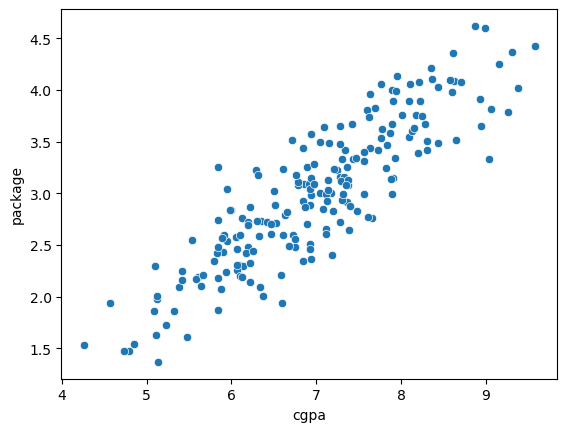

In [7]:
sns.scatterplot(x='cgpa',y='package',data=df);

# Correlation

In [8]:
df.corr()

,cgpa,package
cgpa,1.000000,0.880692
package,0.880692,1.000000


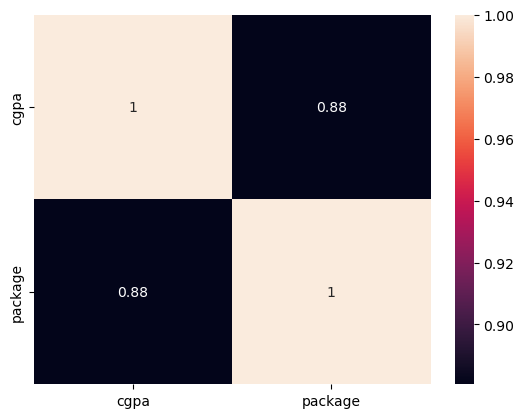

In [9]:
sns.heatmap(df.corr(),annot=True);

# seggregate the data x and y

In [10]:
x=df[['cgpa']]
y=df['package']

## splitting the data into train test split

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=1)

In [12]:
x_train

,cgpa
108,7.76
107,6.33
189,8.11
14,7.73
56,5.84
...,...
133,6.05
137,7.14
72,7.78
140,7.91


In [13]:
y_train

108    3.54
107    2.59
189    4.06
14     3.42
56     2.74
       ... 
133    2.58
137    3.13
72     3.62
140    3.15
37     2.43
Name: package, Length: 160, dtype: float64

In [14]:
x_test

,cgpa
58,6.92
40,9.38
34,7.34
102,5.13
184,7.88
198,7.63
95,6.63
4,6.94
29,7.15
168,8.65


In [15]:
y_test

58     3.09
40     4.02
34     3.42
102    1.37
184    3.14
198    3.96
95     2.79
4      3.57
29     3.49
168    3.52
171    3.76
18     2.98
11     2.60
89     2.72
110    3.76
118    2.88
159    4.08
35     2.87
136    2.10
59     3.31
51     3.79
16     2.35
44     1.86
94     2.42
31     3.89
162    2.55
38     4.36
28     2.24
193    1.94
27     2.16
47     3.26
165    4.08
194    3.67
177    3.64
176    3.23
97     2.84
174    2.99
73     4.03
69     2.94
172    2.51
Name: package, dtype: float64

In [16]:
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(160, 1) (160,)
(40, 1) (40,)


In [17]:
lr=LinearRegression()

In [18]:
lr.fit(x_train,y_train)

LinearRegression()

In [19]:
c=lr.intercept_ # y intercept
c

-1.0859839580358033

In [20]:
m=lr.coef_ # slope
m

array([0.58154877])

## evaluate the model perfromance

In [21]:
y_pred_test=lr.predict(x_test)
y_pred_test

array([2.9383335 , 4.36894346, 3.18258398, 1.89736121, 3.49662031,
       3.35123312, 2.76968435, 2.94996447, 3.07208971, 3.94441286,
       3.57222165, 2.94996447, 2.75805338, 2.64755911, 3.67108494,
       3.2174769 , 3.97930579, 2.90925606, 2.19395108, 3.31052471,
       4.29915761, 2.8918096 , 1.87409926, 2.30444534, 3.62456104,
       2.12998071, 3.9269664 , 2.36841571, 1.5716939 , 2.06601035,
       2.31026083, 3.6885314 , 3.5024358 , 3.03719679, 2.57195777,
       2.39167766, 3.170953  , 3.82228762, 3.15932203, 2.94414898])

In [28]:
y_pred_train=lr.predict(x_train)
y_pred_train

array([3.42683446, 2.59521972, 3.63037653, 3.409388  , 2.31026083,
       3.2640008 , 2.31026083, 3.23492337, 2.58358875, 2.43820156,
       3.38612605, 1.87991474, 3.21166142, 2.67663655, 2.6068507 ,
       3.06627422, 3.69434689, 2.47890997, 2.53124936, 3.51406677,
       4.17121688, 2.6998985 , 2.7464224 , 2.37423119, 2.0427484 ,
       3.5024358 , 2.85691667, 2.78713082, 3.93278188, 1.88573023,
       2.90344057, 1.39141378, 3.14769105, 2.37423119, 3.91533542,
       2.94996447, 4.113062  , 3.05464325, 2.86273216, 1.95551608,
       3.0313813 , 3.04882776, 2.46146351, 1.89154572, 3.14769105,
       2.94414898, 2.15905815, 2.31026083, 2.55451131, 3.49080482,
       2.75805338, 2.39749314, 3.15932203, 3.47335836, 3.53151324,
       3.01393484, 2.94414898, 3.10698264, 3.31634019, 2.83947021,
       2.96741093, 2.89762508, 2.53124936, 3.20003044, 3.46172738,
       2.28118339, 1.69963463, 2.57777326, 2.82783923, 3.90370445,
       2.92088703, 2.97322642, 4.14213944, 3.33378666, 3.68271

In [30]:
r2_score(y_train,y_pred_train)


0.7854731543001223

In [22]:
MAE=mae(y_test,y_pred_test)
MAE

0.29931188593316804

In [23]:
MSE=mse(y_test,y_pred_test)
MSE

0.1370062519255722

In [24]:
rmse=np.sqrt(MSE)
rmse

0.370143555834182

In [25]:
r2=r2_score(y_test,y_pred_test)
r2

0.7283345498058083

In [ ]:
r2_score(y)

**from this r2_score i can say that 
your cgpa which is your input columns is able to explain the 72% of variance in package column**

from this output i can say that performance is  not much good since linear regression is a high bias model

In [28]:
# adjusted r2_score
1-((1-r2)*(x_test.shape[0]-1))/(x_test.shape[0]-x_test.shape[1]-1)



0.7211854590112243

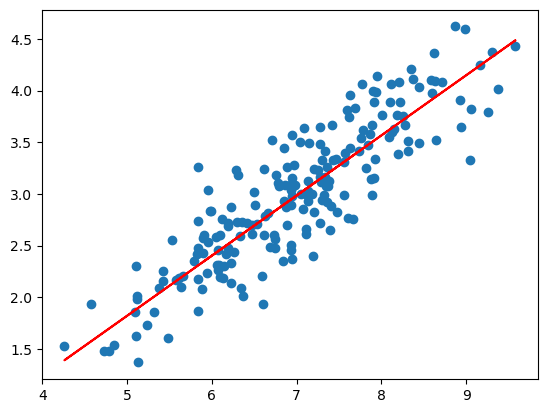

In [56]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_train['cgpa'],lr.predict(x_train),color='red')


In [57]:
# now calculating the r2_score manually

In [63]:
df1=pd.DataFrame()

In [64]:
df1['x_test']=x_test['cgpa']
df1

,x_test
58,6.92
40,9.38
34,7.34
102,5.13
184,7.88
198,7.63
95,6.63
4,6.94
29,7.15
168,8.65


In [67]:
df1['y_test']=y_test
df1

,x_test,y_test
58,6.92,3.09
40,9.38,4.02
34,7.34,3.42
102,5.13,1.37
184,7.88,3.14
198,7.63,3.96
95,6.63,2.79
4,6.94,3.57
29,7.15,3.49
168,8.65,3.52


In [68]:
df1['y_pred']=y_pred_test

In [69]:
df1

,x_test,y_test,y_pred
58,6.92,3.09,2.938333
40,9.38,4.02,4.368943
34,7.34,3.42,3.182584
102,5.13,1.37,1.897361
184,7.88,3.14,3.496620
198,7.63,3.96,3.351233
95,6.63,2.79,2.769684
4,6.94,3.57,2.949964
29,7.15,3.49,3.072090
168,8.65,3.52,3.944413


In [71]:
df1['residual']=df1['y_test']-df1['y_pred']

In [72]:
df1

,x_test,y_test,y_pred,residual
58,6.92,3.09,2.938333,0.151667
40,9.38,4.02,4.368943,-0.348943
34,7.34,3.42,3.182584,0.237416
102,5.13,1.37,1.897361,-0.527361
184,7.88,3.14,3.496620,-0.356620
198,7.63,3.96,3.351233,0.608767
95,6.63,2.79,2.769684,0.020316
4,6.94,3.57,2.949964,0.620036
29,7.15,3.49,3.072090,0.417910
168,8.65,3.52,3.944413,-0.424413


In [73]:
df1['residual_square']=df1['residual']**2

In [74]:
df1

,x_test,y_test,y_pred,residual,residual_square
58,6.92,3.09,2.938333,0.151667,2.300273e-02
40,9.38,4.02,4.368943,-0.348943,1.217615e-01
34,7.34,3.42,3.182584,0.237416,5.636637e-02
102,5.13,1.37,1.897361,-0.527361,2.781098e-01
184,7.88,3.14,3.496620,-0.356620,1.271780e-01
198,7.63,3.96,3.351233,0.608767,3.705971e-01
95,6.63,2.79,2.769684,0.020316,4.127255e-04
4,6.94,3.57,2.949964,0.620036,3.844441e-01
29,7.15,3.49,3.072090,0.417910,1.746490e-01
168,8.65,3.52,3.944413,-0.424413,1.801263e-01


In [76]:
rss=df1['residual_square'].sum()
rss

5.480250077022889

In [77]:
df1['y_test'].mean()              

3.1045000000000003

In [78]:
df1['y_test-y_test_mean']=df1['y_test']-3.1045000000000003

In [79]:
df1

,x_test,y_test,y_pred,residual,residual_square,y_test-y_test_mean
58,6.92,3.09,2.938333,0.151667,2.300273e-02,-0.0145
40,9.38,4.02,4.368943,-0.348943,1.217615e-01,0.9155
34,7.34,3.42,3.182584,0.237416,5.636637e-02,0.3155
102,5.13,1.37,1.897361,-0.527361,2.781098e-01,-1.7345
184,7.88,3.14,3.496620,-0.356620,1.271780e-01,0.0355
198,7.63,3.96,3.351233,0.608767,3.705971e-01,0.8555
95,6.63,2.79,2.769684,0.020316,4.127255e-04,-0.3145
4,6.94,3.57,2.949964,0.620036,3.844441e-01,0.4655
29,7.15,3.49,3.072090,0.417910,1.746490e-01,0.3855
168,8.65,3.52,3.944413,-0.424413,1.801263e-01,0.4155


In [80]:
df1['y_test-y_test_mean_square']=df1['y_test-y_test_mean']**2

In [81]:
df1

,x_test,y_test,y_pred,residual,residual_square,y_test-y_test_mean,y_test-y_test_mean_square
58,6.92,3.09,2.938333,0.151667,2.300273e-02,-0.0145,0.00021
40,9.38,4.02,4.368943,-0.348943,1.217615e-01,0.9155,0.83814
34,7.34,3.42,3.182584,0.237416,5.636637e-02,0.3155,0.09954
102,5.13,1.37,1.897361,-0.527361,2.781098e-01,-1.7345,3.00849
184,7.88,3.14,3.496620,-0.356620,1.271780e-01,0.0355,0.00126
198,7.63,3.96,3.351233,0.608767,3.705971e-01,0.8555,0.73188
95,6.63,2.79,2.769684,0.020316,4.127255e-04,-0.3145,0.09891
4,6.94,3.57,2.949964,0.620036,3.844441e-01,0.4655,0.21669
29,7.15,3.49,3.072090,0.417910,1.746490e-01,0.3855,0.14861
168,8.65,3.52,3.944413,-0.424413,1.801263e-01,0.4155,0.17264


In [83]:
tss=df1['y_test-y_test_mean_square'].sum()
tss

20.17279

In [84]:
R2_SCORE=1-(rss/tss)

In [85]:
R2_SCORE

0.7283345498058083